# 06_estacionariedad

Proyecto ARIMA / ARIMAX
Modelación epidemiológica con variables meteorológicas.

# Inicio del análisis  

En la construcción de un modelo de pronóstico basado en ARIMA para un sistema de alertas tempranas del Dengue, el **análisis de estacionariedad** es una etapa central, porque estos modelos requieren que la serie temporal sea **estacionaria en media y varianza**.

A continuación te presento **todo el proceso metodológico y computacional** que puedes aplicar a tu dataset semanal de casos de dengue.

---



# 1. Preparación de la serie temporal

Primero se debe garantizar que la serie esté **ordenada por fecha y con índice temporal**.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Ubicación para guardar datos consolidados
ubicacion_datos_consolidados_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados"
ubicacion_datos_consolidados_marco = ""
# Ubicación para guardar las imágenes
ubicacion_imagenes_janis = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Gráficos\06_ Estacionariedad"
ubicacion_imagenes_marco = ""

In [3]:
path_janis_datos_procesados = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\df_modelo_rezagos_acumulados.xlsx"
path_marco = ""

# OJO: la bd procesados contiene solo las variables seleccionadas para el modelo, con rezagos promedios acumulados, y con casos_ln (logaritmo natural de casos) en lugar de casos_dengue

datos_procesados= pd.read_excel(path_janis_datos_procesados)



In [4]:
datos_procesados.head()

,fecha,año,semana_epi,casos_ln,hum_esp_mean_lag1_8,temp_max_mean_lag1_6,dias_lluvia_mean_lag3_8,vel_vi_max_mean_lag1_6,sst_mean_lag8_12
0,2021-03-28,2021,13,-1.667348,-1.562145,1.365041,-1.182512,-0.938982,-1.471154
1,2021-04-04,2021,14,-2.254057,-1.654439,1.404736,-1.541751,-1.065262,-1.429517
2,2021-04-11,2021,15,-2.254057,-1.653274,1.303132,-1.721370,-1.107518,-1.305834
3,2021-04-18,2021,16,-2.254057,-1.571164,1.166271,-2.080609,-1.227274,-1.389798
4,2021-04-25,2021,17,-2.254057,-1.476318,1.169698,-1.795919,-1.271656,-1.390331



# 2. Inspección visual de la serie

La inspección gráfica permite identificar:

* tendencia
* estacionalidad
* cambios de varianza
* posibles outliers

Usamos Matplotlib.



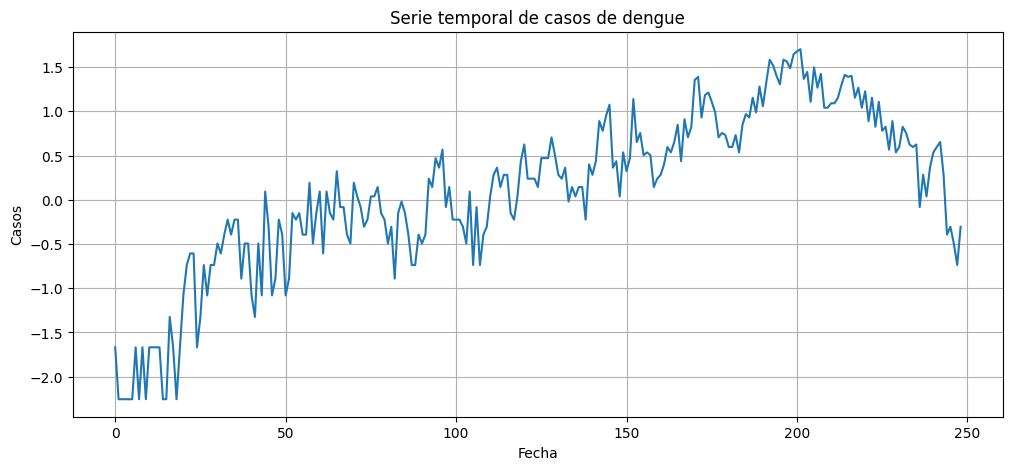

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(datos_procesados.index, datos_procesados['casos_ln'], linestyle='-')

plt.title('Serie temporal de casos de dengue')
plt.xlabel('Fecha')
plt.ylabel('Casos')
plt.grid(True)
plt.show()



### Interpretación

En tu gráfico previo se observan:

* **tendencia creciente**
* **incremento en la variabilidad**
* **picos epidémicos**

Esto sugiere **no estacionariedad**.

---



# 3. Media y varianza móviles

Una forma simple de evaluar estacionariedad es comparar:

* media móvil
* desviación estándar móvil



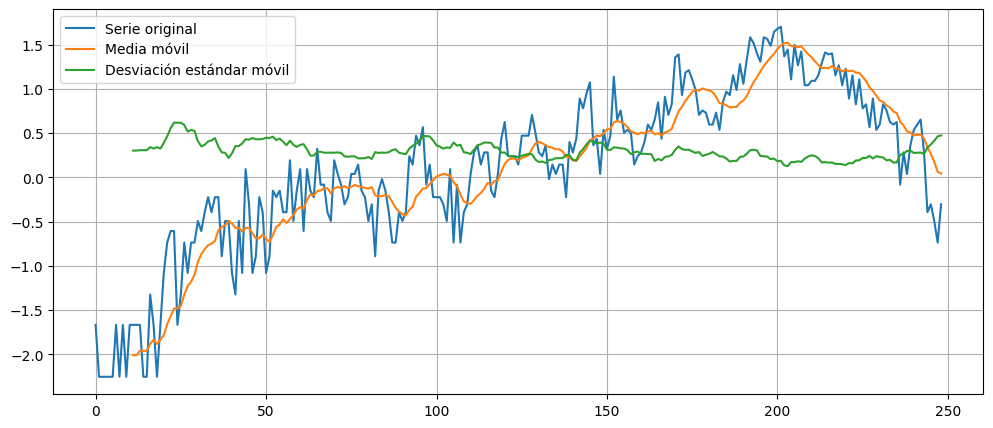

In [6]:
media_movil = datos_procesados['casos_ln'].rolling(window=12).mean()
std_movil = datos_procesados['casos_ln'].rolling(window=12).std()

plt.figure(figsize=(12,5))

plt.plot(datos_procesados.index, datos_procesados['casos_ln'], label='Serie original')
plt.plot(media_movil, label='Media móvil')
plt.plot(std_movil, label='Desviación estándar móvil')

plt.savefig(ubicacion_imagenes_janis + r'\1.serie_casos_dengue_estacionariedad.png', dpi=300)
plt.legend()
plt.grid(True)

plt.show()


```

### Interpretación

Si la serie fuera estacionaria:

* la media sería aproximadamente constante
* la varianza sería aproximadamente constante.

---



# 4. Test estadístico de estacionariedad

Se usa el test de **Augmented Dickey-Fuller test**.

Hipótesis:

$$
H_0 : \text{la serie tiene raíz unitaria (no estacionaria)}
$$

$$
H_1 : \text{la serie es estacionaria}
$$



## Prueba AD Fuller para los datos procesados

In [8]:
datos_procesados.columns

Index(['fecha', 'año', 'semana_epi', 'casos_ln', 'hum_esp_mean_lag1_8',
       'temp_max_mean_lag1_6', 'dias_lluvia_mean_lag3_8',
       'vel_vi_max_mean_lag1_6', 'sst_mean_lag8_12'],
      dtype='object')

In [7]:
from statsmodels.tsa.stattools import adfuller

# --- Aplicar ADF ---
resultado = adfuller(datos_procesados["casos_ln"])

# --- Mostrar resultados ---
print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print("Número de rezagos:", resultado[2])
print("Número de observaciones:", resultado[3])
print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"   {key}: {value}")

# --- Conclusión ---
if resultado[1] <= 0.05:
    print("\n✔ La serie es ESTACIONARIA (no necesita diferenciación).")
else:
    print("\n✘ La serie NO es estacionaria (sí necesita diferenciación).")

ADF Statistic: -2.6967274514842625
p-value: 0.07460627687491245
Número de rezagos: 2
Número de observaciones: 246
Valores críticos:
   1%: -3.457215237265747
   5%: -2.873361841566324
   10%: -2.5730700760129555

✘ La serie NO es estacionaria (sí necesita diferenciación).


```



### Interpretación

Si:

$$
p\text{-value} < 0.05
$$

se rechaza $H_0$ y la serie se considera **estacionaria**.



En datos epidemiológicos normalmente:

$$
p > 0.05
$$

lo que confirma **no estacionariedad**.

---



# 5. Diferenciación de la serie

Para eliminar tendencia se usa diferenciación:

$$
y_t' = y_t - y_{t-1}
$$



## Diferenciación de la serie a datos procesados

In [43]:
datos_procesados.columns

Index(['año', 'semana_epi', 'temp', 'temp_max', 'temp_min', 'hum_esp',
       'hum_rel', 'prec', 'dias_lluvia', 'vel_vi', 'vel_vi_max', 'vel_vi_min',
       'uv', 'soi', 'sst', 'casos_dengue', 'casos_ln', 'prec_ln',
       'dias_lluvia_ln', 'temp_bc', 'temp_max_bc', 'temp_min_bc', 'hum_esp_bc',
       'hum_rel_bc', 'vel_vi_bc', 'vel_vi_max_bc', 'vel_vi_min_bc', 'uv_bc',
       'soi_yj', 'sst_yj'],
      dtype='object')

In [25]:
datos_procesados.columns

Index(['fecha', 'año', 'semana_epi', 'casos_ln', 'hum_esp_mean_lag1_8',
       'temp_max_mean_lag1_6', 'dias_lluvia_mean_lag3_8',
       'vel_vi_max_mean_lag1_6', 'sst_mean_lag8_12'],
      dtype='object')

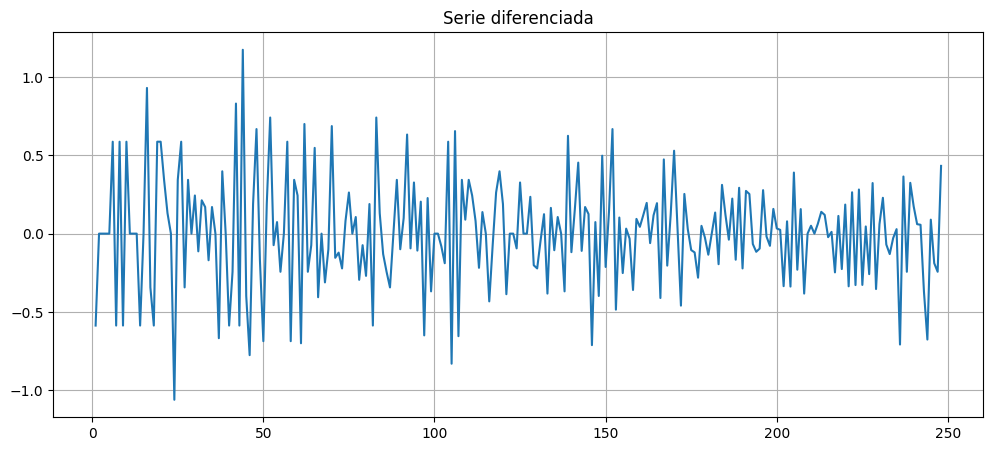

In [8]:
datos_procesados_diferenciados = datos_procesados['casos_ln'].diff().dropna()

plt.figure(figsize=(12,5))
plt.plot(datos_procesados_diferenciados)

plt.title('Serie diferenciada')
plt.grid(True)
plt.savefig(ubicacion_imagenes_janis + r'\2.serie_casos_procesados_diferenciada.png', dpi=300)
plt.show()

## Se repite la prueba

### Datos procesados diferenciados

In [9]:
from statsmodels.tsa.stattools import adfuller

# --- Aplicar ADF ---
resultado = adfuller(datos_procesados_diferenciados)

# --- Mostrar resultados ---
print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])
print("Número de rezagos:", resultado[2])
print("Número de observaciones:", resultado[3])
print("Valores críticos:")

for key, value in resultado[4].items():
    print(f"   {key}: {value}")

# --- Conclusión ---
if resultado[1] <= 0.05:
    print("\n✔ La serie es ESTACIONARIA (no necesita diferenciación).")
else:
    print("\n✘ La serie NO es estacionaria (sí necesita diferenciación).")

ADF Statistic: -8.130400100949531
p-value: 1.094188300329595e-12
Número de rezagos: 6
Número de observaciones: 241
Valores críticos:
   1%: -3.4577787098622674
   5%: -2.873608704758507
   10%: -2.573201765981991

✔ La serie es ESTACIONARIA (no necesita diferenciación).


In [27]:
# =========================================================
# CREAR COLUMNA DIFERENCIADA
# =========================================================

datos_procesados['casos_ln_diff'] = (
    datos_procesados['casos_ln']
    .diff()
)

In [28]:
# =========================================================
# CREAR NUEVO DATAFRAME FINAL PARA MODELADO
# =========================================================

df_modelo_final = datos_procesados[[
    
    'fecha',
    'año',
    'semana_epi',
    
    'casos_ln_diff',
    
    'hum_esp_mean_lag1_8',
    'temp_max_mean_lag1_6',
    'dias_lluvia_mean_lag3_8',
    'vel_vi_max_mean_lag1_6',
    'sst_mean_lag8_12'
    
]].dropna().reset_index(drop=True)

# =========================================================
# VERIFICAR
# =========================================================

print(df_modelo_final.columns)

print('\nDimensiones:')
print(df_modelo_final.shape)

print('\nPrimeras filas:')
print(df_modelo_final.head())

Index(['fecha', 'año', 'semana_epi', 'casos_ln_diff', 'hum_esp_mean_lag1_8',
       'temp_max_mean_lag1_6', 'dias_lluvia_mean_lag3_8',
       'vel_vi_max_mean_lag1_6', 'sst_mean_lag8_12'],
      dtype='object')

Dimensiones:
(248, 9)

Primeras filas:
       fecha   año  semana_epi  casos_ln_diff  hum_esp_mean_lag1_8  \
0 2021-04-04  2021          14       -0.58671            -1.654439   
1 2021-04-11  2021          15        0.00000            -1.653274   
2 2021-04-18  2021          16        0.00000            -1.571164   
3 2021-04-25  2021          17        0.00000            -1.476318   
4 2021-05-02  2021          18        0.00000            -1.401786   

   temp_max_mean_lag1_6  dias_lluvia_mean_lag3_8  vel_vi_max_mean_lag1_6  \
0              1.404736                -1.541751               -1.065262   
1              1.303132                -1.721370               -1.107518   
2              1.166271                -2.080609               -1.227274   
3              1.169698 

In [ ]:
# =========================================================
# GUARDAR DATAFRAME FINAL
# =========================================================

ruta_guardado = (
    ubicacion_datos_consolidados_janis +
    r'\datos_diff.xlsx'
)

df_modelo_final.to_excel(
    ruta_guardado,
    index=False
)

# =========================================================
# VERIFICACIÓN
# =========================================================

print('Dataframe guardado en:')
print(ruta_guardado)

Dataframe guardado en:
C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Datos consolidados\df_modelo_final.xlsx



## la serie se considera **estacionaria después de una diferenciación**, por lo que:

$$
I (d) = 1
$$

en el modelo ARIMA.

---



# 7. Evaluación de estacionalidad

Para datos semanales de dengue suele existir estacionalidad anual:

$$
s = 52
$$

Se puede observar mediante **descomposición temporal**.

```python


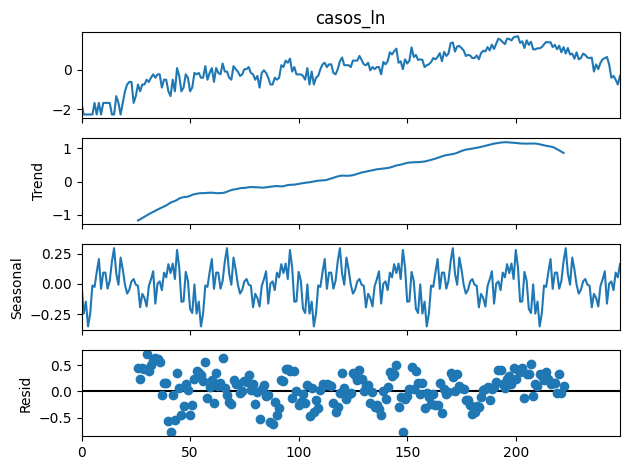

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

descomposicion = seasonal_decompose(
    datos_procesados['casos_ln'],
    model='additive',
    period=52
)

descomposicion.plot()

plt.show()

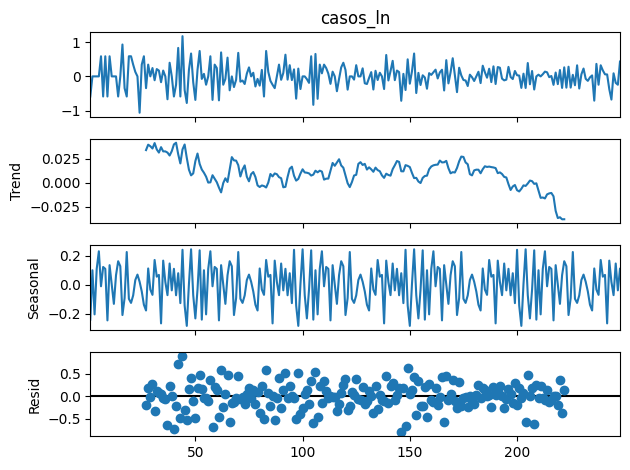

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

descomposicion = seasonal_decompose(
    datos_procesados_diferenciados,
    model='additive',
    period=52
)

descomposicion.plot()

plt.show()


# 8. ACF y PACF

Una vez estacionaria la serie, se analizan:

* autocorrelación
* autocorrelación parcial

para determinar parámetros del modelo.



# PACF y ACF de la serie de datos procesados

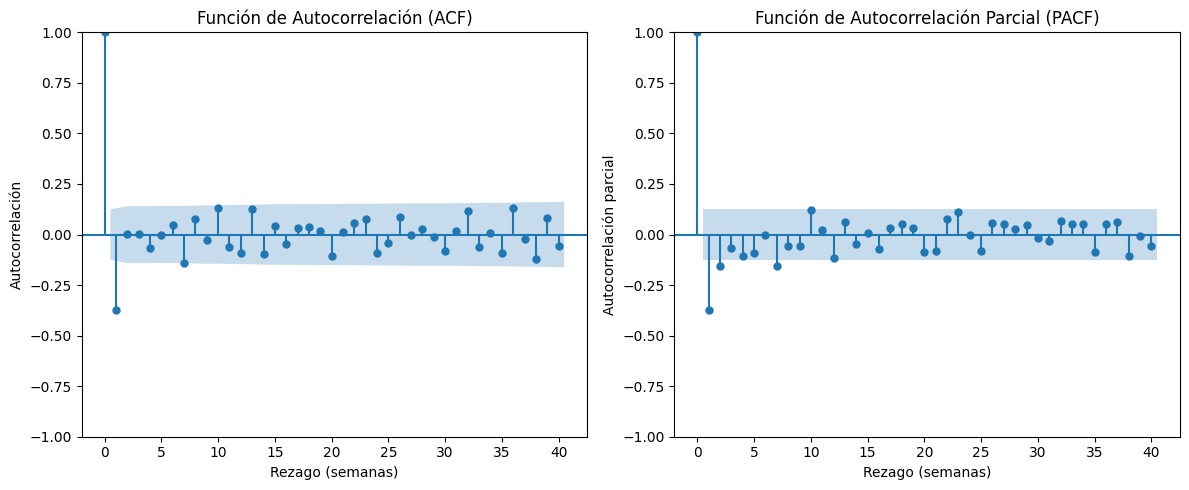

In [20]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Crear figura con dos subgráficos horizontales
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# -------- ACF --------
plot_acf(datos_procesados_diferenciados, lags=40, ax=axes[0])

axes[0].set_title('Función de Autocorrelación (ACF)')
axes[0].set_xlabel('Rezago (semanas)')
axes[0].set_ylabel('Autocorrelación')

# -------- PACF --------
plot_pacf(datos_procesados_diferenciados, lags=40, ax=axes[1])

axes[1].set_title('Función de Autocorrelación Parcial (PACF)')
axes[1].set_xlabel('Rezago (semanas)')
axes[1].set_ylabel('Autocorrelación parcial')

plt.tight_layout()

plt.savefig(ubicacion_imagenes_janis + r'\4.acf_pacf_casos_procesados_diferenciada.png', dpi=300)

plt.show()


En el proceso de identificación de un modelo SARIMAX para la predicción de casos de Dengue, los gráficos de **ACF (Autocorrelation Function)** y **PACF (Partial Autocorrelation Function)** permiten inferir los parámetros autoregresivos y de media móvil del modelo.

Recordemos que un modelo SARIMAX tiene la estructura:

$$
SARIMAX(p,d,q)(P,D,Q)_s
$$

donde:

* $p$: orden autoregresivo
* (d): diferenciación
* (q): orden de media móvil
* $P$: componente autoregresivo estacional
* (D): diferenciación estacional
* (Q): componente de media móvil estacional
* $s$: periodo estacional (para datos semanales de dengue normalmente $s=52$).

---



# 1. Interpretación del gráfico ACF

En el gráfico de **ACF** se observa lo siguiente:

### a) Rezago 0

Como es esperado, la autocorrelación en:

$$
lag = 0
$$

es igual a **1**, ya que toda serie está perfectamente correlacionada consigo misma.

---



### b) Rezago 1–2

Se observa una **autocorrelación negativa significativa alrededor del rezago 3**, que cae fuera del intervalo de confianza.

Esto sugiere la presencia de un **componente de media móvil (MA)** en la serie.

Cuando en el ACF:

* hay un **pico significativo en los primeros rezagos**
* y luego las correlaciones se atenúan rápidamente

esto suele indicar un proceso:

$$
MA(q)
$$

con **q pequeño**, generalmente:

$$
q = 1 \quad \text{o} \quad q = 2
$$

---

### c) Resto de los rezagos

Después del rezago 3, la mayoría de los valores permanecen dentro del intervalo de confianza.

Esto sugiere que:

* no existe una memoria larga significativa
* la estructura temporal es relativamente corta.

---
